# Tuned router classifier: random forest vs logistic regression

The baseline notebook left a logistic router with default settings. Here I tuned that
model properly and put it up against a random forest on the same features and the same
prompt-level split, so the comparison is between algorithms, not between preprocessing
choices.

Tuning choices and why. I searched with 5-fold cross-validation on the training prompts
only, scored by macro F1: with 13 classes this unbalanced, accuracy barely moves when a
model ignores the small classes, and the small classes (the prompts only expensive
models can solve) are exactly the ones a router cannot afford to ignore. For logistic
regression I searched the regularization strength C and class_weight. For the random
forest I fixed 300 trees (more trees only flatten variance, the interesting knobs are
elsewhere) and searched tree depth, minimum leaf size, and class_weight.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_df = pd.read_parquet(
    Path("..") / "data" / "processed" / "prompts_features_labels_tau100.parquet")
long_df = pd.read_parquet(Path("..") / "data" / "processed" / "records_long.parquet")
core = long_df[~long_df.is_reference]

# same split as notebook 02: same random_state, same stratification
train_df, test_df = train_test_split(
    model_df, test_size=0.2, random_state=42, stratify=model_df.dataset)
feature_cols = ["dataset", "query_chars", "med_prompt_tokens"]
print(f"train {len(train_df):,} prompts, test {len(test_df):,} prompts")

train 9,732 prompts, test 2,434 prompts


In [2]:
prep = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["dataset"]),
    ("num", StandardScaler(), ["query_chars", "med_prompt_tokens"]),
])

logit_search = GridSearchCV(
    Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=3000))]),
    param_grid={"clf__C": [0.1, 1, 10],
                "clf__class_weight": [None, "balanced"]},
    cv=5, scoring="f1_macro", n_jobs=-1)
logit_search.fit(train_df[feature_cols], train_df.label)
print("logistic best params:", logit_search.best_params_)
print(f"logistic best CV macro F1: {logit_search.best_score_:.3f}")

logistic best params: {'clf__C': 10, 'clf__class_weight': None}
logistic best CV macro F1: 0.119


In [3]:
rf_search = GridSearchCV(
    Pipeline([("prep", prep),
              ("clf", RandomForestClassifier(n_estimators=300, random_state=42))]),
    param_grid={"clf__max_depth": [None, 12, 20],
                "clf__min_samples_leaf": [1, 5],
                "clf__class_weight": [None, "balanced"]},
    cv=5, scoring="f1_macro", n_jobs=-1)
rf_search.fit(train_df[feature_cols], train_df.label)
print("random forest best params:", rf_search.best_params_)
print(f"random forest best CV macro F1: {rf_search.best_score_:.3f}")

random forest best params: {'clf__class_weight': None, 'clf__max_depth': None, 'clf__min_samples_leaf': 1}
random forest best CV macro F1: 0.150


In [4]:
# classification metrics on the held-out test prompts
lookup = core[core.prompt_id.isin(test_df.prompt_id)].set_index(
    ["prompt_id", "model"])[["cost", "score"]]

def economic(picks):
    got = lookup.loc[list(zip(picks.index, picks.values, strict=True))]
    return got.cost.mean(), got.score.mean()

results = []
for name, search in [("logistic (tuned)", logit_search),
                     ("random forest (tuned)", rf_search)]:
    pred = search.predict(test_df[feature_cols])
    cost, score = economic(pd.Series(pred, index=test_df.prompt_id))
    results.append({
        "model": name,
        "accuracy": accuracy_score(test_df.label, pred),
        "macro F1": f1_score(test_df.label, pred, average="macro"),
        "routed mean cost (USD)": cost,
        "routed mean score": score,
    })
pd.DataFrame(results).set_index("model").round(4)

,accuracy,macro F1,routed mean cost (USD),routed mean score
model,,,,
logistic (tuned),0.4897,0.1200,0.0115,0.5637
random forest (tuned),0.4047,0.1451,0.0073,0.5362


Tuning left the logistic model basically where the baseline notebook had it (best C = 10,
no class weighting), so its numbers repeat the baseline: accuracy 0.49, macro F1 0.12.
The forest trades four points of accuracy for better macro F1 (0.145) and a visibly
cheaper routing bill: $0.0073 per prompt against $0.0115, at 0.536 mean score against
0.564. Neither dominates the other. The forest delivers about 95 percent of the logistic
router's quality for about 63 percent of its price, so per dollar it is the stronger
router, and it also wins the metric I tuned for. The class_weight="balanced" variants
lost the search on both models, which surprised me at first, but with the label mass
this concentrated, reweighting makes the models overpredict the rare expensive classes
and the hoped-for macro gain does not show up in cross-validation.

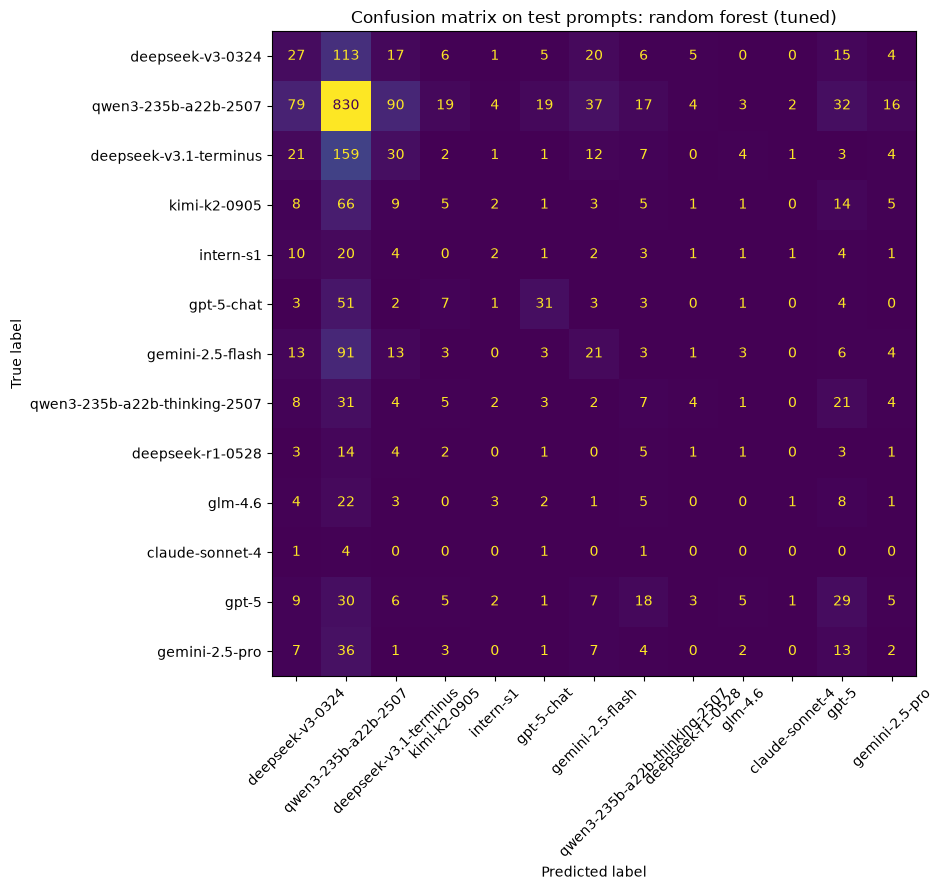

winner by test macro F1: random forest (tuned)


In [5]:
# confusion matrix for the better router, classes ordered cheap to expensive
from sklearn.metrics import ConfusionMatrixDisplay

order = core.groupby("model")["cost"].mean().sort_values().index.tolist()
best_name, best_search = max(
    [("logistic (tuned)", logit_search), ("random forest (tuned)", rf_search)],
    key=lambda kv: f1_score(test_df.label, kv[1].predict(test_df[feature_cols]),
                            average="macro"))
best_pred = best_search.predict(test_df[feature_cols])
fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay.from_predictions(
    test_df.label, best_pred, labels=order, xticks_rotation=45,
    ax=ax, colorbar=False, values_format="d")
ax.set_title(f"Confusion matrix on test prompts: {best_name}")
plt.tight_layout()
plt.show()
print("winner by test macro F1:", best_name)

The matrix reads better than a 40 percent accuracy suggests once cost enters the
picture. The heavy diagonal cell is qwen3-235b-a22b-2507, the true label for 47 percent
of test prompts, and most off-diagonal mass sits between that model and the other two
budget picks (deepseek-v3-0324, deepseek-v3.1-terminus). Those three are within a
fraction of a cent of each other per prompt, so confusing them barely costs anything.
The mistakes that matter are the rows where the true label is a frontier model and the
router sent the prompt to the budget cluster anyway: answer quality is what gets lost
there, and that is most of the remaining gap to the oracle.

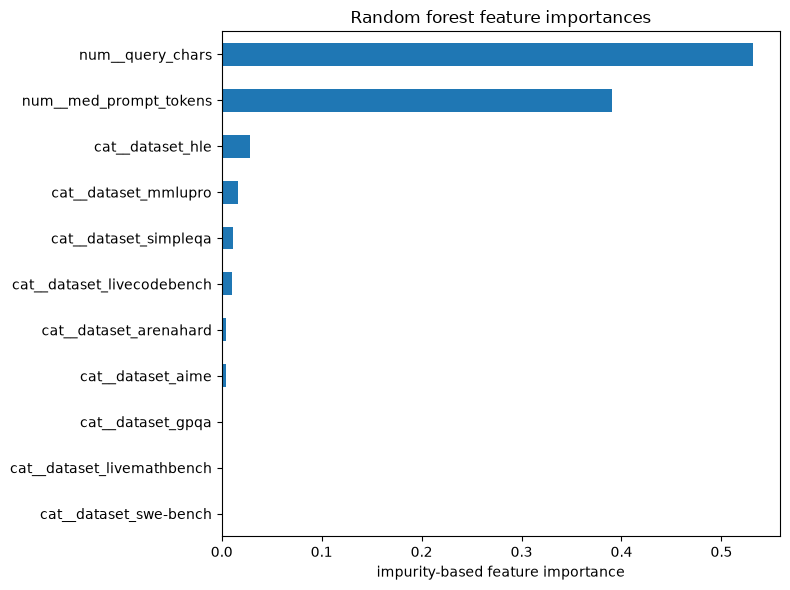

In [6]:
# what the forest actually leans on
rf_best = rf_search.best_estimator_
feat_names = rf_best.named_steps["prep"].get_feature_names_out()
importances = pd.Series(rf_best.named_steps["clf"].feature_importances_,
                        index=feat_names).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
importances.plot.barh(ax=ax)
ax.set_xlabel("impurity-based feature importance")
ax.set_title("Random forest feature importances")
plt.tight_layout()
plt.show()

Prompt size carries the forest: query characters (0.53) and median prompt tokens (0.39)
account for over 90 percent of the split importance, with the dataset dummies far
behind (hle leads them at 0.03). I read that with some caution rather than as proof
that task category does not matter: prompt sizes differ systematically across datasets,
so part of the category signal rides inside the numeric features, and impurity
importances also favor continuous features over one-hot dummies. The plainer takeaway
is that the light feature set works mostly through prompt length, which is known the
moment a request arrives.

In [7]:
# save test predictions for the comparison notebook
out = Path("..") / "data" / "processed"
preds = test_df[["prompt_id"]].copy()
preds["logistic_tuned"] = logit_search.predict(test_df[feature_cols])
preds["random_forest_tuned"] = rf_search.predict(test_df[feature_cols])
preds.to_parquet(out / "router_test_predictions.parquet", index=False)
print("saved", len(preds), "test predictions")

saved 2434 test predictions
